In [1]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import classification_report
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Flatten, Dropout, Input, MaxPooling1D, BatchNormalization
warnings.filterwarnings('ignore')
import yfinance as yf

curr = os.getcwd()
project_root = os.path.abspath(os.path.join(curr, '..', '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

from ai.features import FEATURES
from ai.help_folder.backtest import backtest, production_backtest, filter_signals
from ai.help_folder.help import prepare_data,calculate_base_features, save_models, generate_final_report, download, optimize_threshold, stage1, stage2, save_artifacts_json, print_stage_report

In [ ]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

TICKER = "AAPL"                  
START_DATE = "2010-01-01"       
END_DATE = "2023-12-31"          
INTERVAL = "1d"        

TRAIN_SPLIT = 0.70               
VAL_SPLIT = 0.15               
TEST_SPLIT = 0.15
SEQUENCE_LENGTH = 20         
 
CNN_UNITS = 32
DENSE_UNITS = 32
DROPOUT_RATE = 0.5       
LEARNING_RATE = 0.001
BATCH_SIZE = 32
EPOCHS = 30                     
PATIENCE_ES = 1              
PATIENCE_LR = 5   

MOVE_THRESHOLD = 0.01 
HORIZON = 5                  
COMMISSION = 0.001 
SLIPPAGE = 0.0005 
MAX_POSITION_SIZE = 0.10 
MAX_DRAWDOWN = 0.15  

TOP_K_PERCENT = 15
L2_REG = 0.1
SHORT_BASE_TH = 30
LONG_BASE_TH = 70

MODEL_PATH = '../models/model_cnn'

In [ ]:
from tensorflow.keras import layers, regularizers, Sequential
import tensorflow as tf

def create_model(input_shape, name="cnn_model"):
    reg = regularizers.l2(L2_REG) 
    model = Sequential(name=name)
    model.add(layers.Input(shape=input_shape))

    model.add(layers.Conv1D(
        filters=CNN_UNITS, 
        kernel_size=3, 
        activation='relu', 
        padding='same',
        kernel_regularizer=reg
    ))
    model.add(layers.BatchNormalization()) 
    model.add(layers.MaxPooling1D(pool_size=2))
    model.add(layers.Dropout(DROPOUT_RATE)) 
    model.add(layers.Flatten())
    
    model.add(layers.Dense(
        units=DENSE_UNITS, 
        activation='relu',
        kernel_regularizer=reg
    ))
    model.add(layers.Dropout(DROPOUT_RATE)) 
    model.add(layers.Dense(1, activation='sigmoid'))
    optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
    
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

In [4]:
# ЗАГРУЗКА ДАННЫХ
raw_data, raw_df = download(TICKER, START_DATE, END_DATE, interval=INTERVAL)
print(f"📊 Загружено {len(raw_df)} записей")

spy = yf.download("SPY", start=START_DATE, end=END_DATE, progress=False)
vix = yf.download("^VIX", start=START_DATE, end=END_DATE, progress=False)

spy.columns = spy.columns.get_level_values(0)
vix.columns = vix.columns.get_level_values(0)
print(f"Загружено: {len(raw_data)}")
# ПОДГОТОВКА ДАННЫХ
print("\n🔧 Подготовка данных...")
df = calculate_base_features(raw_df)
df = df.dropna().reset_index(drop=True)

res_prepare_data = prepare_data(
    df, TRAIN_SPLIT, VAL_SPLIT, SEQUENCE_LENGTH,
    move_threshold=MOVE_THRESHOLD, horizon=HORIZON, FEATURES1=FEATURES
)

📊 Загружено 3522 записей
Загружено: 3522

🔧 Подготовка данных...
✅ Создано 34 признаков. Всего строк: 3522
✅ Train: 2441 | Val: 508 | Test: 508


In [5]:
# STAGE 1: MOVE and HOLD
res_stage1 = stage1(
    res_prepare_data['X_train'], 
    res_prepare_data['X_val'], 
    res_prepare_data['X_test'],
    res_prepare_data['y1_train'], 
    res_prepare_data['y1_val'], 
    res_prepare_data['y1_test'],
    res_prepare_data['cw1'],
    create_model=create_model, 
    EPOCHS=EPOCHS,
    BATCH_SIZE=BATCH_SIZE,
    PATIENCE_ES=PATIENCE_ES,
    PATIENCE_LR=PATIENCE_LR
)


 STAGE 1: MOVE vs HOLD (Volatility/Activity Filter)
Epoch 1/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5342 - loss: 6.8212 - val_accuracy: 0.5335 - val_loss: 4.4264 - learning_rate: 0.0010
Epoch 2/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 918us/step - accuracy: 0.5756 - loss: 3.3472 - val_accuracy: 0.5531 - val_loss: 2.4236 - learning_rate: 0.0010
Epoch 3/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 901us/step - accuracy: 0.5830 - loss: 1.9337 - val_accuracy: 0.5315 - val_loss: 1.5569 - learning_rate: 0.0010
Epoch 4/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 961us/step - accuracy: 0.6247 - loss: 1.2739 - val_accuracy: 0.5512 - val_loss: 1.1362 - learning_rate: 0.0010
Epoch 5/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 950us/step - accuracy: 0.6256 - loss: 0.9706 - val_accuracy: 0.5610 - val_loss: 0.9150 - learning_rate: 0.0010
Epoch 6/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 965us/step - accuracy: 0.6284 - loss: 0.8246 - val_accuracy: 0.5197 - val_loss: 0.8788 - learning_rate: 0.0010
Epoch 7/30
77/77 ━━━━━━━━━━━━━━━━━━━━

In [6]:
# STAGE 2: UP and DOWN
res_stage2 = stage2(
    X_train=res_prepare_data['X_train'],
    X_val=res_prepare_data['X_val'],
    X_test=res_prepare_data['X_test'],
    y2_train=res_prepare_data['y2_train'],
    y2_val=res_prepare_data['y2_val'],
    y2_test=res_prepare_data['y2_test'],
    mask1_train=res_stage1['mask_train'],
    mask1_val=res_stage1['mask_val'],
    mask1_test=res_stage1['mask_test'],
    create_model=create_model,
    EPOCHS=EPOCHS,
    BATCH_SIZE=BATCH_SIZE,
    PATIENCE_ES=PATIENCE_ES
)


 STAGE 2: UP vs DOWN (Directional Model)
Обучение на 2024 сбалансированных примерах (50/50)
Epoch 1/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4960 - loss: 7.7352 - val_accuracy: 0.6194 - val_loss: 5.5871
Epoch 2/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5242 - loss: 4.5374 - val_accuracy: 0.6020 - val_loss: 3.4310
Epoch 3/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 976us/step - accuracy: 0.5227 - loss: 2.8697 - val_accuracy: 0.4701 - val_loss: 2.2838
Epoch 4/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 968us/step - accuracy: 0.5469 - loss: 1.9169 - val_accuracy: 0.5423 - val_loss: 1.6014
Epoch 5/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 976us/step - accuracy: 0.5573 - loss: 1.3947 - val_accuracy: 0.5473 - val_loss: 1.2259
Epoch 6/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 971us/step - accuracy: 0.5558 - loss: 1.0986 - val_accuracy: 0.5821 - val_loss: 1.0140
Epoch 7/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 990us/step - accuracy: 0.5820 - loss: 0.9281 - val_accuracy: 0.4652 - val_loss: 0.9317
Epoch 8/30
64/6

In [7]:
print_stage_report(
    res_prepare_data['y1_test'],
    res_stage1['mask_test'].astype(int), 
    "Stage 1 (MOVE vs HOLD)",
    ['HOLD', 'MOVE']
)

temp_preds_s2 = (res_stage2['probs_full'] >= 0.5).astype(int)
print_stage_report(
    res_prepare_data['y2_test'],
    temp_preds_s2,
    "Stage 2 (UP vs DOWN) - Raw Performance",
    ['DOWN', 'UP']
)


Stage 1 (MOVE vs HOLD):
              precision    recall  f1-score   support

        HOLD       0.60      0.33      0.42       249
        MOVE       0.55      0.80      0.65       259

    accuracy                           0.56       508
   macro avg       0.58      0.56      0.54       508
weighted avg       0.58      0.56      0.54       508


Stage 2 (UP vs DOWN) - Raw Performance:
              precision    recall  f1-score   support

        DOWN       0.55      0.45      0.49       238
          UP       0.58      0.69      0.63       270

    accuracy                           0.57       508
   macro avg       0.57      0.57      0.56       508
weighted avg       0.57      0.57      0.57       508



In [ ]:
from ai.help_folder.backtest import get_statistical_signals
y_pred_final = get_statistical_signals(
    res_stage1['probs_test'], 
    res_stage2['probs_full'], 
    top_k_percent=TOP_K_PERCENT,
    short_base_th=SHORT_BASE_TH,
    long_base_th=LONG_BASE_TH
)

print(f"Сигналы BUY: {np.sum(y_pred_final == 1)}")
print(f"Сигналы SELL: {np.sum(y_pred_final == -1)}")

Сигналы BUY: 23
Сигналы SELL: 23


ROC AUC Stage 1: 0.5749
ROC AUC Stage 2: 0.5826


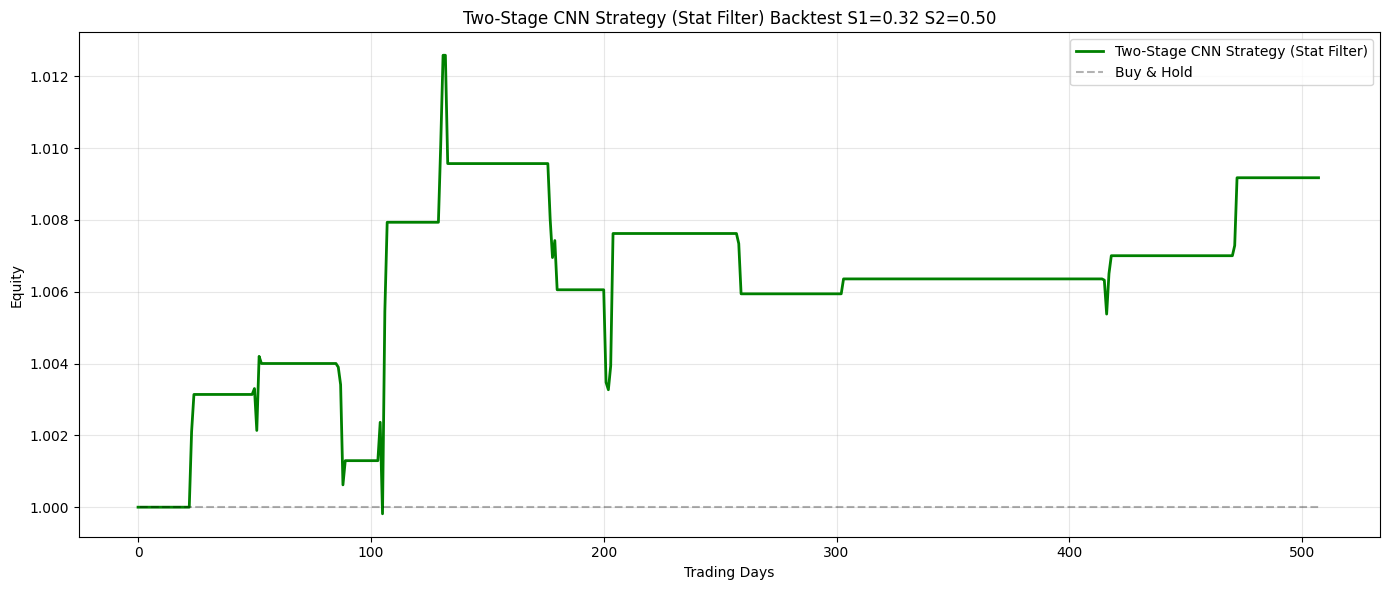

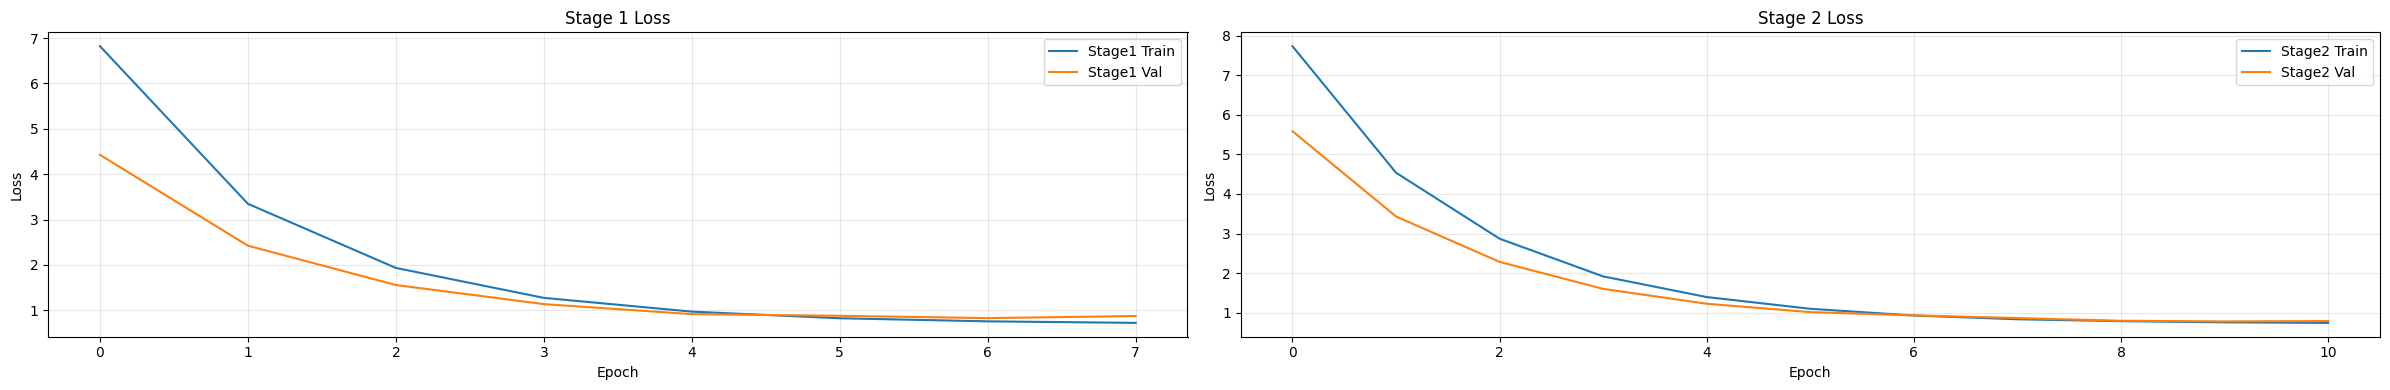

In [9]:
from sklearn.metrics import roc_auc_score

auc_s1 = roc_auc_score(res_prepare_data['y1_test'], res_stage1['probs_test'])
print(f"ROC AUC Stage 1: {auc_s1:.4f}")

mask = res_stage1['mask_test']
y2_true_filtered = res_prepare_data['y2_test'][mask]
valid_idx = ~np.isnan(y2_true_filtered)

if len(y2_true_filtered[valid_idx]) > 0:
    auc_s2 = roc_auc_score(y2_true_filtered[valid_idx], res_stage2['probs_filtered'][valid_idx])
    print(f"ROC AUC Stage 2: {auc_s2:.4f}")
else:
    print("Stage 2 AUC: недостаточно данных для расчета")

results = production_backtest(
    df_test=res_prepare_data['df_test'],
    signals=y_pred_final,  
    commission=COMMISSION,
    slippage=SLIPPAGE,
    max_position_size=MAX_POSITION_SIZE,
    horizon=HORIZON
)

history_stages = [res_stage1['history'], res_stage2['history']]
thresholds = {"S1": res_stage1['threshold'], "S2": 0.5}

backtest(
    results=results,
    history_stages=history_stages,
    strategy_name="Two-Stage CNN Strategy (Stat Filter)",
    thresholds=thresholds,
    save_dir="../models/model_cnn"
)


In [10]:
s1_f1 = res_stage1.get('f1_val', 0.0) 
s2_threshold = 0.5 
s2_f1 = 0.0 

params = { 
    'threshold_stage1': res_stage1['threshold'],
    'threshold_stage2': s2_threshold,
    'move_threshold': MOVE_THRESHOLD,
    'horizon': HORIZON,
    'commission': COMMISSION,
    'slippage': SLIPPAGE,
    'max_position_size': MAX_POSITION_SIZE,
    'max_drawdown': MAX_DRAWDOWN,
    'sequence_length': SEQUENCE_LENGTH
}

backtest_results = {
    "total_return": results.get('total_return', 0),
    "sharpe_ratio": results.get('sharpe', results.get('sharpe_ratio', 0)),
    "max_drawdown": results.get('max_drawdown', 0),
    "win_rate": results.get('win_rate', 0),
    "trades": results.get('trades', 0),
    "avg_pnl": results.get('avg_pnl', 0)
}

save_artifacts_json(
    base_dir=MODEL_PATH,
    strategy_name="two_stage",
    res_stage1=res_stage1,
    res_stage2=res_stage2,
    FEATURES=FEATURES,
    params=params,
    backtest_results=backtest_results
)

save_models(
    model_stage1=res_stage1['model'],
    model_stage2=res_stage2['model'],
    scaler=res_prepare_data['scaler'],
    params=params,
    base_dir=MODEL_PATH,
    features=FEATURES
)

generate_final_report(
    results=results,
    model_type="two_stage",
    stage1_metrics={
        "threshold": res_stage1['threshold'],
        "f1": s1_f1
    },
    stage2_metrics={
        "threshold": s2_threshold,
        "f1": s2_f1
    },
    ml_metrics={
        "Stage 1 F1": s1_f1,
        "Stage 2 F1": s2_f1
    }
)

✅ JSON summary saved: ../models/model_cnn/two_stage/artifacts_summary.json
✅ Model Stage 1 saved: ../models/model_cnn/strategy/model_stage1.h5
✅ Model Stage 2 saved: ../models/model_cnn/strategy/model_stage2.h5
✅ Scaler, features, and params (WITH features list) saved to ../models/model_cnn/strategy

📁 Все артефакты сохранены в ../models/model_cnn/strategy

📋 ИТОГОВЫЙ ОТЧЁТ

🎯 Two-Stage Classification:
   Stage 1: MOVE vs HOLD (Threshold=0.32, F1=0.5719)
   Stage 2: UP vs DOWN (Threshold=0.5, F1=0.0000)

Метрики:
   Stage 1 F1: 0.5719
   Stage 2 F1: 0.0000

💰 Production Backtest:
   Total Return: 0.9%
   Sharpe Ratio: 0.59
   Max Drawdown: 0.9%
Trades: 13
   Win Rate: 61.5%
